## STEP 1 — Mount Google Drive & Verifikasi Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

# Sesuaikan path ini dengan lokasi folder dataset kamu di Google Drive
DATASET_PATH = '/content/drive/MyDrive/Braille Dataset'

if os.path.exists(DATASET_PATH):
    classes = sorted(os.listdir(DATASET_PATH))
    print(f"Dataset ditemukan: {DATASET_PATH}")
    print(f"Jumlah kelas: {len(classes)}")
    print(f"Kelas: {classes}")
    total = 0
    for cls in classes:
        cls_path = os.path.join(DATASET_PATH, cls)
        if os.path.isdir(cls_path):
            n = len(os.listdir(cls_path))
            print(f"  [{cls}]: {n} gambar")
            total += n
    print(f"Total gambar: {total}")
else:
    print(f"Folder tidak ditemukan: {DATASET_PATH}")
    print("Upload dataset ke Google Drive terlebih dahulu.")

Dataset ditemukan: /content/drive/MyDrive/Braille Dataset
Jumlah kelas: 26
Kelas: ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
  [a]: 60 gambar
  [b]: 60 gambar
  [c]: 60 gambar
  [d]: 60 gambar
  [e]: 60 gambar
  [f]: 60 gambar
  [g]: 60 gambar
  [h]: 60 gambar
  [i]: 60 gambar
  [j]: 60 gambar
  [k]: 60 gambar
  [l]: 60 gambar
  [m]: 60 gambar
  [n]: 60 gambar
  [o]: 60 gambar
  [p]: 60 gambar
  [q]: 60 gambar
  [r]: 60 gambar
  [s]: 60 gambar
  [t]: 60 gambar
  [u]: 60 gambar
  [v]: 60 gambar
  [w]: 60 gambar
  [x]: 60 gambar
  [y]: 60 gambar
  [z]: 60 gambar
Total gambar: 1560


## STEP 2 — Install & Import Library

In [ ]:
!pip install opencv-python-headless -q

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import random
import json
from tqdm import tqdm

print("Library berhasil diimport")
print(f"OpenCV: {cv2.__version__}")
print(f"NumPy: {np.__version__}")

Library berhasil diimport
OpenCV: 4.13.0
NumPy: 2.0.2


## STEP 3 — Exploratory Data Analysis (EDA)

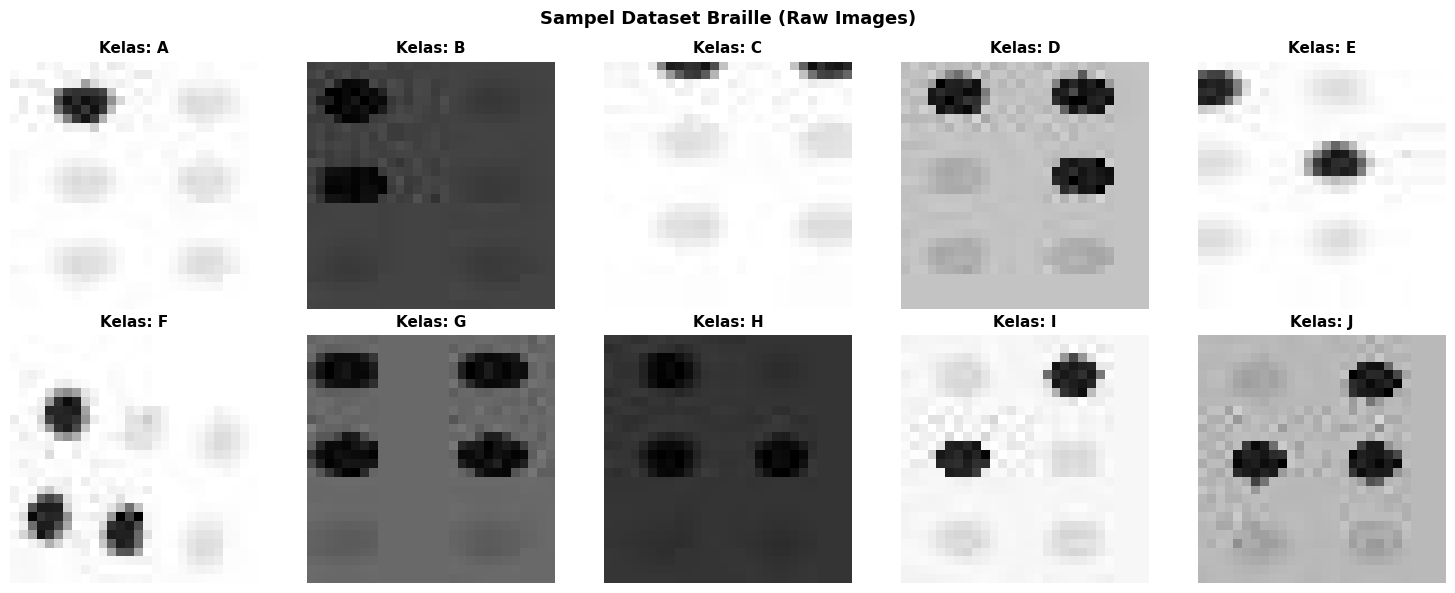

In [ ]:
def load_sample_images(dataset_path, n_samples=1):
    samples = {}
    for cls in sorted(os.listdir(dataset_path)):
        cls_dir = os.path.join(dataset_path, cls)
        if not os.path.isdir(cls_dir):
            continue
        images = [f for f in os.listdir(cls_dir)
                  if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))]
        if images:
            chosen = random.sample(images, min(n_samples, len(images)))
            samples[cls] = [os.path.join(cls_dir, img) for img in chosen]
    return samples

samples = load_sample_images(DATASET_PATH, n_samples=1)
classes_to_show = sorted(samples.keys())[:10]

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i, cls in enumerate(classes_to_show):
    img_path = samples[cls][0]
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[i].imshow(img_rgb)
    axes[i].set_title(f'Kelas: {cls.upper()}', fontsize=11, fontweight='bold')
    axes[i].axis('off')

plt.suptitle('Sampel Dataset Braille (Raw Images)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/eda_sample_raw.png', dpi=150, bbox_inches='tight')
plt.show()

Tinggi - Min: 28, Max: 28, Rata-rata: 28.0
Lebar  - Min: 28, Max: 28, Rata-rata: 28.0


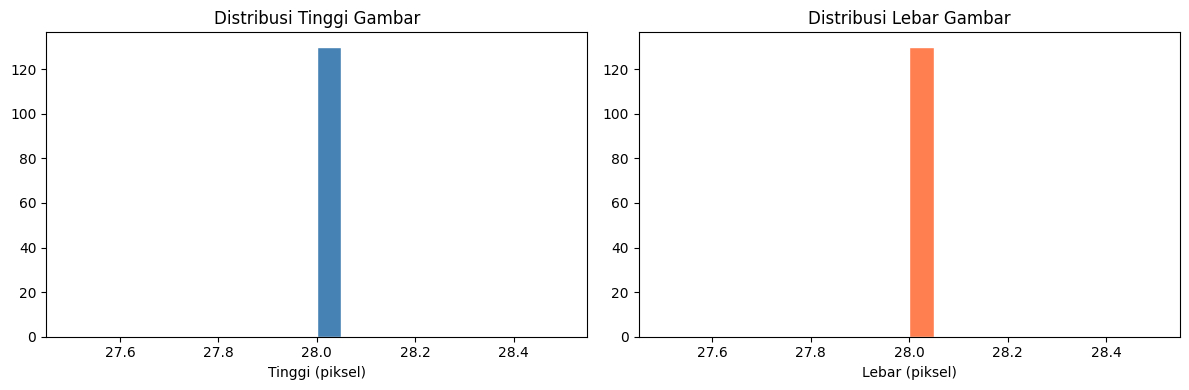

In [ ]:
# Analisis ukuran gambar
sizes = []
for cls in sorted(os.listdir(DATASET_PATH)):
    cls_dir = os.path.join(DATASET_PATH, cls)
    if not os.path.isdir(cls_dir):
        continue
    for fname in os.listdir(cls_dir)[:5]:
        if not fname.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
            continue
        img = cv2.imread(os.path.join(cls_dir, fname))
        if img is not None:
            h, w = img.shape[:2]
            sizes.append((h, w))

if sizes:
    heights, widths = zip(*sizes)
    print(f"Tinggi - Min: {min(heights)}, Max: {max(heights)}, Rata-rata: {np.mean(heights):.1f}")
    print(f"Lebar  - Min: {min(widths)}, Max: {max(widths)}, Rata-rata: {np.mean(widths):.1f}")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.hist(heights, bins=20, color='steelblue', edgecolor='white')
    ax1.set_title('Distribusi Tinggi Gambar')
    ax1.set_xlabel('Tinggi (piksel)')
    ax2.hist(widths, bins=20, color='coral', edgecolor='white')
    ax2.set_title('Distribusi Lebar Gambar')
    ax2.set_xlabel('Lebar (piksel)')
    plt.tight_layout()
    plt.savefig('/content/eda_size_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()

## STEP 4 — Konfigurasi & Fungsi Preprocessing

Pipeline preprocessing (sesuai dokumen BrailleVision):
1. Grayscale Conversion
2. Gaussian Blur
3. Adaptive Thresholding
4. Morphological Operations (Erosi + Dilasi)
5. Resize

In [ ]:
# Konfigurasi preprocessing — sesuaikan jika perlu
CONFIG = {
    'target_size'      : (64, 64),  # ukuran output (width, height)
    'thresh_block_size': 11,        # ukuran blok adaptive threshold (harus ganjil)
    'thresh_C'         : 2,         # konstanta pengurangan dari mean lokal
    'morph_kernel_size': 2,         # ukuran kernel erosi/dilasi
    'morph_iterations' : 1,         # jumlah iterasi morfologi
    'output_dir'       : '/content/preprocessed_dataset',
}

print("Konfigurasi Preprocessing:")
for k, v in CONFIG.items():
    print(f"  {k}: {v}")

Konfigurasi Preprocessing:
  target_size: (64, 64)
  thresh_block_size: 11
  thresh_C: 2
  morph_kernel_size: 2
  morph_iterations: 1
  output_dir: /content/preprocessed_dataset


In [ ]:
def preprocess_braille_image(img_bgr, config=CONFIG, verbose=False):
    """
    Pipeline preprocessing lengkap untuk gambar sel Braille.

    Parameters:
    -----------
    img_bgr : numpy array - gambar input BGR (output default OpenCV)
    config  : dict        - parameter preprocessing
    verbose : bool        - jika True, return semua tahap intermediate

    Returns:
    --------
    final   : numpy array - gambar hasil preprocessing (grayscale binary 64x64)
    steps   : dict        - (hanya jika verbose=True) semua tahapan
    """
    steps = {}
    steps['0_original'] = img_bgr.copy()

    # Tahap 1: Grayscale
    if len(img_bgr.shape) == 3:
        gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    else:
        gray = img_bgr.copy()
    steps['1_grayscale'] = gray.copy()

    # Tahap 2: Gaussian Blur
    blurred = cv2.GaussianBlur(gray, (3, 3), 0)
    steps['2_blurred'] = blurred.copy()

    # Tahap 3: Adaptive Thresholding
    # Mengatasi pencahayaan tidak merata dengan membandingkan
    # setiap piksel terhadap rata-rata tetangga lokalnya.
    binary = cv2.adaptiveThreshold(
        blurred,
        maxValue=255,
        adaptiveMethod=cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        thresholdType=cv2.THRESH_BINARY_INV,  # titik Braille jadi putih
        blockSize=config['thresh_block_size'],
        C=config['thresh_C']
    )
    steps['3_adaptive_threshold'] = binary.copy()

    # Tahap 4: Morphological Operations
    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (config['morph_kernel_size'], config['morph_kernel_size'])
    )
    eroded  = cv2.erode(binary, kernel, iterations=config['morph_iterations'])
    steps['4a_eroded'] = eroded.copy()

    dilated = cv2.dilate(eroded, kernel, iterations=config['morph_iterations'])
    steps['4b_dilated'] = dilated.copy()

    # Tahap 5: Resize ke ukuran standar
    final = cv2.resize(dilated, config['target_size'], interpolation=cv2.INTER_AREA)
    steps['5_final'] = final.copy()

    if verbose:
        return final, steps
    return final

print("Fungsi preprocess_braille_image berhasil didefinisikan.")

Fungsi preprocess_braille_image berhasil didefinisikan.


## STEP 5 — Visualisasi Pipeline (per gambar)

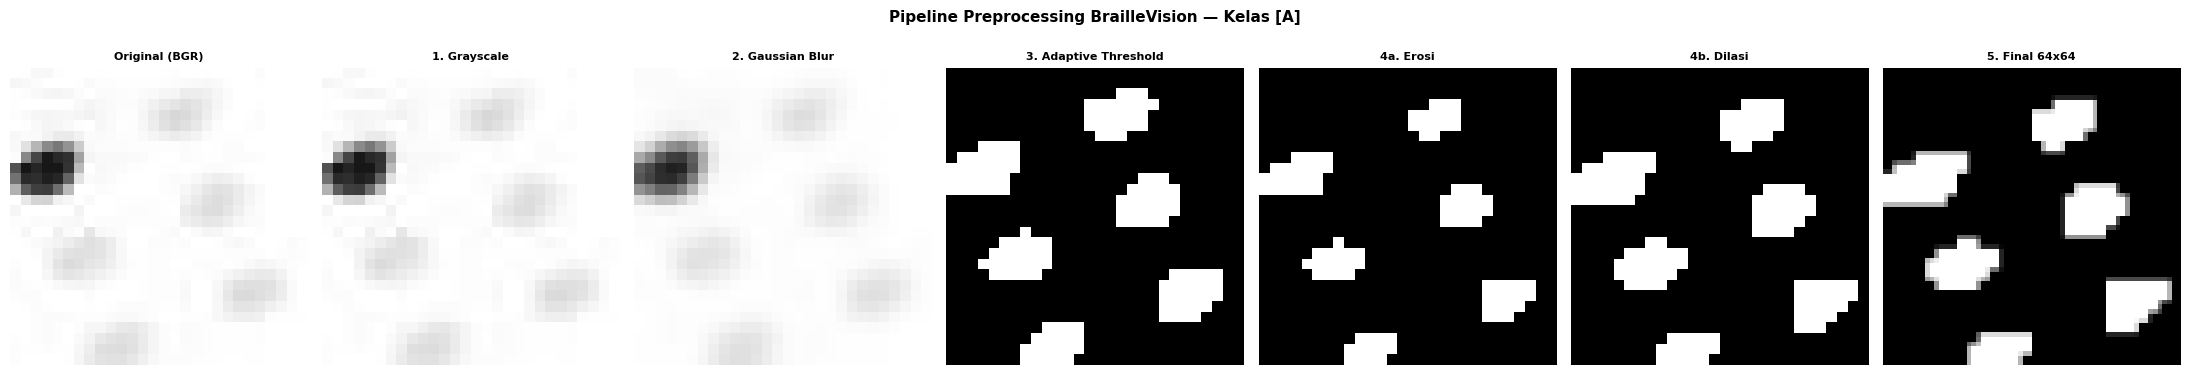

Disimpan ke /content/pipeline_a.png


In [ ]:
def visualize_pipeline(img_path, config=CONFIG):
    """Visualisasi setiap tahap preprocessing untuk satu gambar."""
    img = cv2.imread(img_path)
    if img is None:
        print(f"Gagal membaca: {img_path}")
        return

    _, steps = preprocess_braille_image(img, config, verbose=True)

    step_labels = [
        ('0_original',           'Original (BGR)'),
        ('1_grayscale',          '1. Grayscale'),
        ('2_blurred',            '2. Gaussian Blur'),
        ('3_adaptive_threshold', '3. Adaptive Threshold'),
        ('4a_eroded',            '4a. Erosi'),
        ('4b_dilated',           '4b. Dilasi'),
        ('5_final',              '5. Final 64x64'),
    ]

    fig, axes = plt.subplots(1, 7, figsize=(22, 4))

    for ax, (key, label) in zip(axes, step_labels):
        img_step = steps[key]
        if key == '0_original':
            ax.imshow(cv2.cvtColor(img_step, cv2.COLOR_BGR2RGB))
        else:
            ax.imshow(img_step, cmap='gray', vmin=0, vmax=255)
        ax.set_title(label, fontsize=8, fontweight='bold')
        ax.axis('off')
        h, w = img_step.shape[:2]
        ax.set_xlabel(f'{w}x{h}', fontsize=7, color='gray')

    cls_name = os.path.basename(os.path.dirname(img_path))
    plt.suptitle(f'Pipeline Preprocessing BrailleVision — Kelas [{cls_name.upper()}]',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'/content/pipeline_{cls_name}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Disimpan ke /content/pipeline_{cls_name}.png")


# Demo: jalankan pada gambar pertama dari kelas pertama
sample_cls   = sorted(os.listdir(DATASET_PATH))[0]
sample_dir   = os.path.join(DATASET_PATH, sample_cls)
sample_files = [f for f in os.listdir(sample_dir)
                if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

if sample_files:
    sample_path = os.path.join(sample_dir, sample_files[0])
    visualize_pipeline(sample_path)

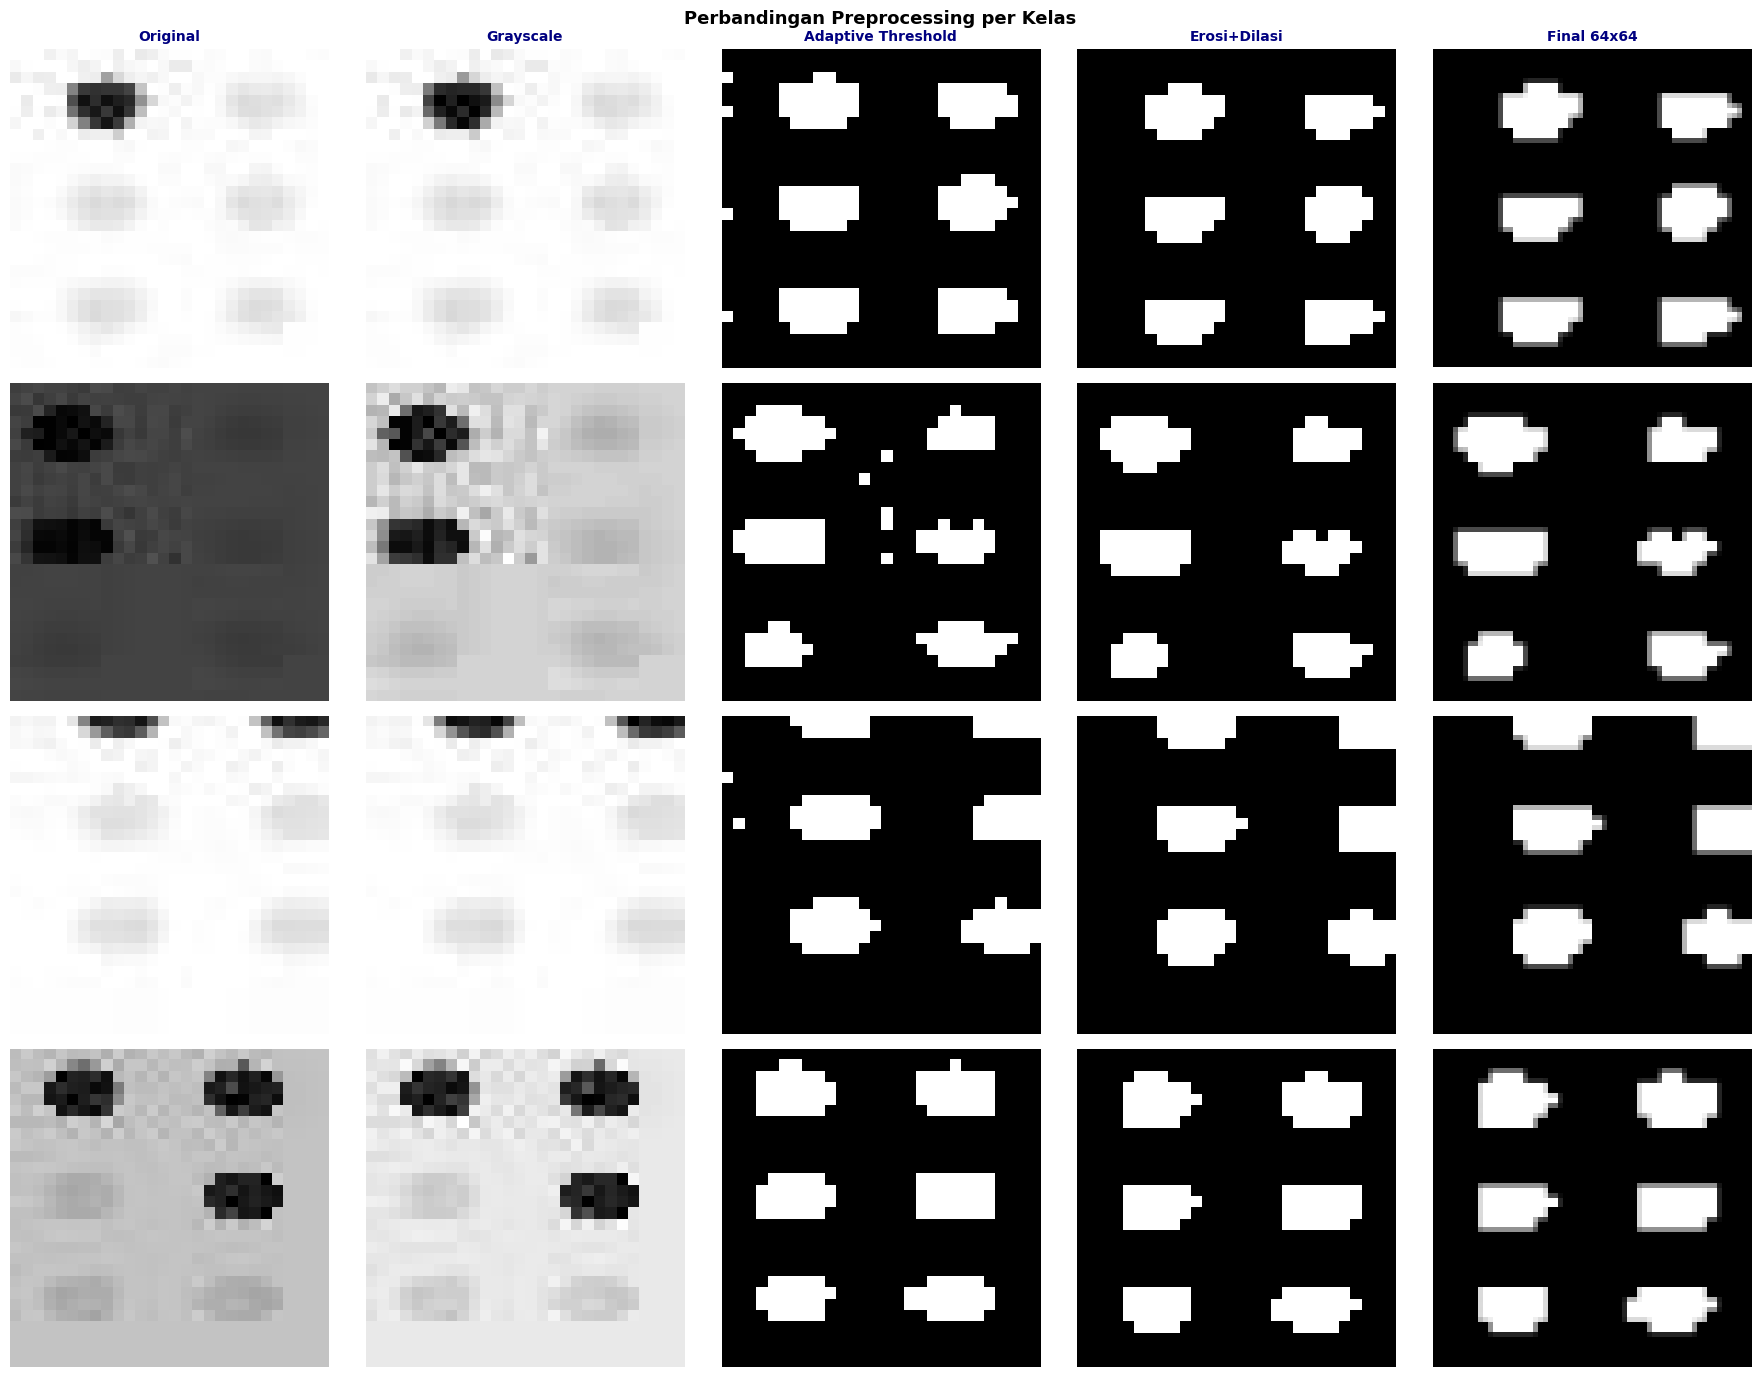

In [ ]:
# Visualisasi 4 kelas sekaligus
classes_sample = sorted(samples.keys())[:4]
fig, axes = plt.subplots(4, 5, figsize=(18, 14))

stage_names = ['Original', 'Grayscale', 'Adaptive Threshold', 'Erosi+Dilasi', 'Final 64x64']
for col, stage in enumerate(stage_names):
    axes[0, col].set_title(stage, fontsize=10, fontweight='bold', color='navy')

for row, cls in enumerate(classes_sample):
    img_path = samples[cls][0]
    img = cv2.imread(img_path)
    _, steps = preprocess_braille_image(img, CONFIG, verbose=True)
    key_order = ['0_original', '1_grayscale', '3_adaptive_threshold', '4b_dilated', '5_final']
    for col, key in enumerate(key_order):
        img_step = steps[key]
        if key == '0_original':
            axes[row, col].imshow(cv2.cvtColor(img_step, cv2.COLOR_BGR2RGB))
        else:
            axes[row, col].imshow(img_step, cmap='gray')
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(f'Kelas [{cls.upper()}]', fontsize=10,
                             fontweight='bold', rotation=0, labelpad=50)

plt.suptitle('Perbandingan Preprocessing per Kelas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/preprocessing_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## STEP 6 — Segmentasi Sel Braille (Projection Profile)

Digunakan untuk gambar Braille yang berisi **lebih dari satu karakter**.
Horizontal & Vertical Projection Profile menghitung akumulasi piksel hitam
per baris dan per kolom untuk menemukan batas antar sel.

In [ ]:
def compute_projection_profile(binary_img):
    """
    Hitung Horizontal dan Vertical Projection Profile.
    - h_proj: jumlah piksel putih per baris
    - v_proj: jumlah piksel putih per kolom
    """
    norm = binary_img / 255.0 if binary_img.max() > 1 else binary_img.astype(float)
    h_proj = np.sum(norm, axis=1)
    v_proj = np.sum(norm, axis=0)
    return h_proj, v_proj


def find_segments(projection, threshold=0.5, min_gap=3):
    """
    Temukan segmen (area berkonten) dari projection profile.
    Returns list of (start, end) indices.
    """
    has_content = projection > threshold
    segments = []
    in_segment = False
    start = 0
    gap_count = 0

    for i, active in enumerate(has_content):
        if active:
            if not in_segment:
                start = i
                in_segment = True
            gap_count = 0
        else:
            if in_segment:
                gap_count += 1
                if gap_count >= min_gap:
                    segments.append((start, i - gap_count))
                    in_segment = False
                    gap_count = 0

    if in_segment:
        segments.append((start, len(has_content) - 1))
    return segments


def segment_braille_cells(binary_img, threshold=0.5, min_gap=3):
    """
    Segmentasi gambar Braille multi-karakter menjadi sel individual.
    Returns cells (list array) dan bboxes (list of r_start,r_end,c_start,c_end).
    """
    h_proj, v_proj = compute_projection_profile(binary_img)
    row_segs = find_segments(h_proj, threshold, min_gap)
    col_segs = find_segments(v_proj, threshold, min_gap)

    cells, bboxes = [], []
    for r_start, r_end in row_segs:
        for c_start, c_end in col_segs:
            cell = binary_img[r_start:r_end+1, c_start:c_end+1]
            if cell.size > 0:
                cells.append(cell)
                bboxes.append((r_start, r_end, c_start, c_end))

    return cells, bboxes

print("Fungsi segmentasi (Projection Profile) berhasil didefinisikan.")

Fungsi segmentasi (Projection Profile) berhasil didefinisikan.


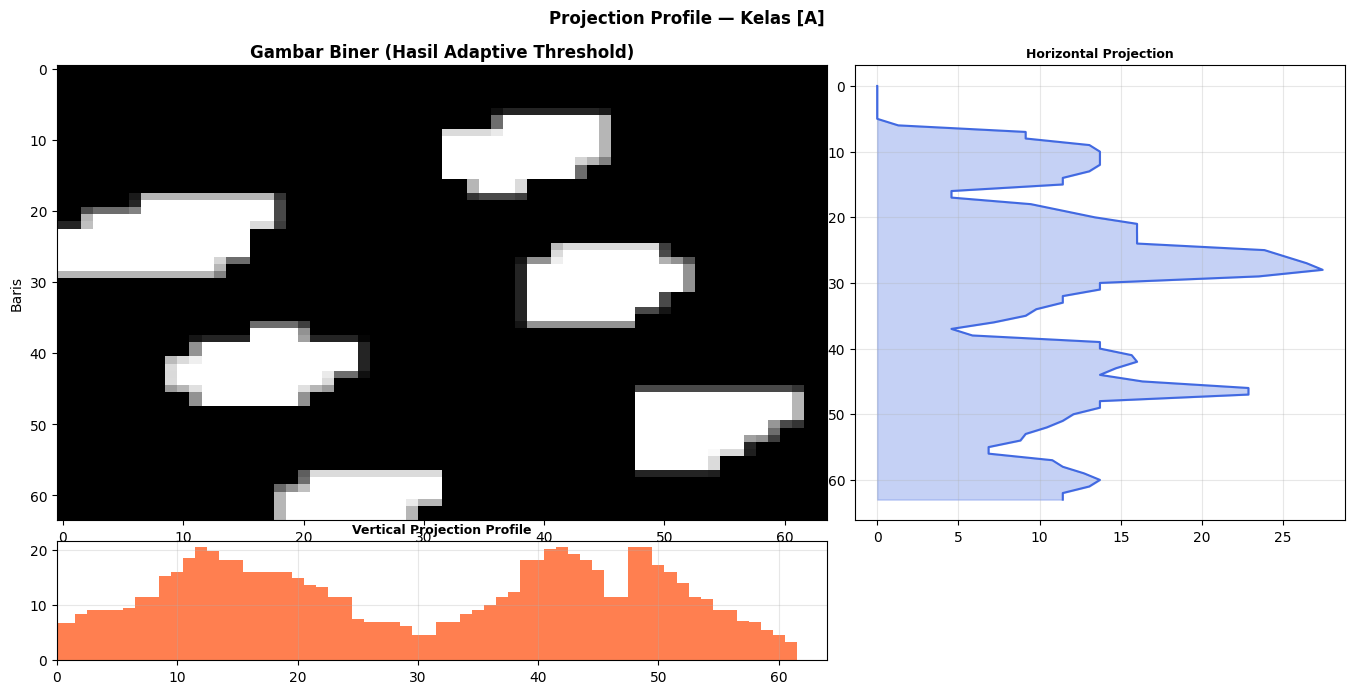

Disimpan ke /content/projection_profile.png


In [ ]:
def visualize_projection_profile(binary_img, title="Projection Profile"):
    h_proj, v_proj = compute_projection_profile(binary_img)

    fig = plt.figure(figsize=(14, 7))
    ax_img   = fig.add_axes([0.05, 0.25, 0.55, 0.65])
    ax_hproj = fig.add_axes([0.62, 0.25, 0.35, 0.65])
    ax_vproj = fig.add_axes([0.05, 0.05, 0.55, 0.17])

    ax_img.imshow(binary_img, cmap='gray', aspect='auto')
    ax_img.set_title('Gambar Biner (Hasil Adaptive Threshold)', fontweight='bold')
    ax_img.set_xlabel('Kolom')
    ax_img.set_ylabel('Baris')

    ax_hproj.plot(h_proj, np.arange(len(h_proj)), color='royalblue')
    ax_hproj.fill_betweenx(np.arange(len(h_proj)), 0, h_proj, alpha=0.3, color='royalblue')
    ax_hproj.set_title('Horizontal Projection', fontweight='bold', fontsize=9)
    ax_hproj.invert_yaxis()
    ax_hproj.grid(alpha=0.3)

    ax_vproj.bar(np.arange(len(v_proj)), v_proj, color='coral', width=1.0)
    ax_vproj.set_title('Vertical Projection Profile', fontweight='bold', fontsize=9)
    ax_vproj.set_xlim([0, len(v_proj)])
    ax_vproj.grid(alpha=0.3)

    plt.suptitle(title, fontsize=12, fontweight='bold', y=0.98)
    plt.savefig('/content/projection_profile.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Disimpan ke /content/projection_profile.png")


img_demo = cv2.imread(sample_path)
processed_demo = preprocess_braille_image(img_demo)
visualize_projection_profile(processed_demo,
    title=f"Projection Profile — Kelas [{sample_cls.upper()}]")

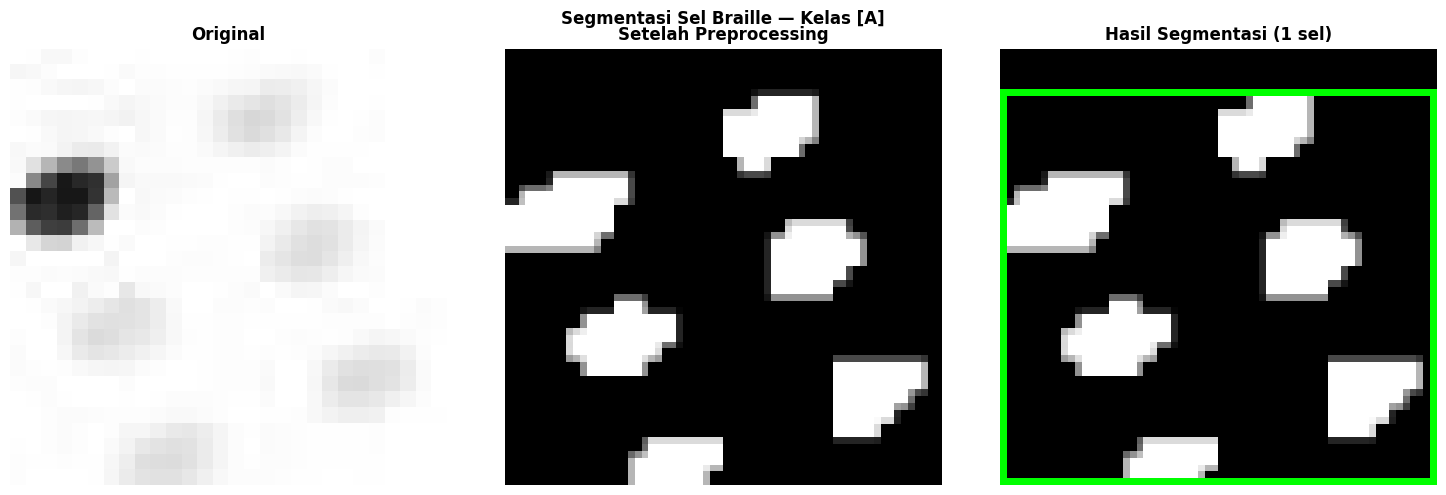

Total sel terdeteksi: 1


In [ ]:
def visualize_segmentation(img_path, config=CONFIG):
    img = cv2.imread(img_path)
    processed = preprocess_braille_image(img, config)
    cells, bboxes = segment_braille_cells(processed)

    img_boxes = cv2.cvtColor(processed, cv2.COLOR_GRAY2BGR)
    for (r_start, r_end, c_start, c_end) in bboxes:
        cv2.rectangle(img_boxes, (c_start, r_start), (c_end, r_end), (0, 255, 0), 1)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[0].set_title('Original', fontweight='bold')
    axes[0].axis('off')

    axes[1].imshow(processed, cmap='gray')
    axes[1].set_title('Setelah Preprocessing', fontweight='bold')
    axes[1].axis('off')

    axes[2].imshow(cv2.cvtColor(img_boxes, cv2.COLOR_BGR2RGB))
    axes[2].set_title(f'Hasil Segmentasi ({len(cells)} sel)', fontweight='bold')
    axes[2].axis('off')

    cls_name = os.path.basename(os.path.dirname(img_path))
    plt.suptitle(f'Segmentasi Sel Braille — Kelas [{cls_name.upper()}]',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'/content/segmentation_{cls_name}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Total sel terdeteksi: {len(cells)}")
    return cells, bboxes

cells, bboxes = visualize_segmentation(sample_path)

## STEP 7 — Proses & Simpan Seluruh Dataset

In [ ]:
def process_full_dataset(dataset_path, output_dir, config=CONFIG):
    """
    Proses seluruh dataset dengan pipeline preprocessing,
    simpan ke folder output dengan struktur subfolder per kelas.
    """
    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)

    stats = {'total_processed': 0, 'total_failed': 0, 'per_class': {}}
    classes = sorted([d for d in os.listdir(dataset_path)
                      if os.path.isdir(os.path.join(dataset_path, d))])

    print(f"Memulai preprocessing dataset...")
    print(f"Input : {dataset_path}")
    print(f"Output: {output_dir}")
    print(f"Kelas : {len(classes)}")

    for cls in tqdm(classes, desc="Memproses kelas"):
        cls_input  = os.path.join(dataset_path, cls)
        cls_output = output_path / cls
        cls_output.mkdir(parents=True, exist_ok=True)

        image_files = [f for f in os.listdir(cls_input)
                       if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))]

        ok, fail = 0, 0
        for fname in image_files:
            in_path  = os.path.join(cls_input, fname)
            out_path = cls_output / (Path(fname).stem + '_prep.png')
            try:
                img = cv2.imread(in_path)
                if img is None:
                    fail += 1
                    continue
                result = preprocess_braille_image(img, config)
                cv2.imwrite(str(out_path), result)
                ok += 1
            except Exception as e:
                print(f"Gagal: {in_path} — {e}")
                fail += 1

        stats['per_class'][cls] = {'processed': ok, 'failed': fail}
        stats['total_processed'] += ok
        stats['total_failed']    += fail

    with open(output_path / 'stats.json', 'w') as f:
        json.dump(stats, f, indent=2)

    print(f"Selesai! Berhasil: {stats['total_processed']}, Gagal: {stats['total_failed']}")
    return stats


stats = process_full_dataset(DATASET_PATH, CONFIG['output_dir'])

Memulai preprocessing dataset...
Input : /content/drive/MyDrive/Braille Dataset
Output: /content/preprocessed_dataset
Kelas : 26


Memproses kelas: 100%|██████████| 26/26 [06:44<00:00, 15.57s/it]

Selesai! Berhasil: 1560, Gagal: 0


In [ ]:
# Verifikasi hasil output
output_path = CONFIG['output_dir']
classes_out = sorted([c for c in os.listdir(output_path)
                      if os.path.isdir(os.path.join(output_path, c))])
total_out = 0
for cls in classes_out:
    n = len(os.listdir(os.path.join(output_path, cls)))
    total_out += n
    print(f"  [{cls}]: {n} gambar")
print(f"Total gambar preprocessed: {total_out}")
print(f"Lokasi: {output_path}")

  [a]: 60 gambar
  [b]: 60 gambar
  [c]: 60 gambar
  [d]: 60 gambar
  [e]: 60 gambar
  [f]: 60 gambar
  [g]: 60 gambar
  [h]: 60 gambar
  [i]: 60 gambar
  [j]: 60 gambar
  [k]: 60 gambar
  [l]: 60 gambar
  [m]: 60 gambar
  [n]: 60 gambar
  [o]: 60 gambar
  [p]: 60 gambar
  [q]: 60 gambar
  [r]: 60 gambar
  [s]: 60 gambar
  [t]: 60 gambar
  [u]: 60 gambar
  [v]: 60 gambar
  [w]: 60 gambar
  [x]: 60 gambar
  [y]: 60 gambar
  [z]: 60 gambar
Total gambar preprocessed: 1560
Lokasi: /content/preprocessed_dataset


## STEP 8 — Simpan Dataset ke Google Drive

In [ ]:
# Zip dan simpan ke Google Drive
print("Mengompres dataset...")
import subprocess
subprocess.run(['zip', '-r', '/content/preprocessed_dataset.zip',
                '/content/preprocessed_dataset/'], capture_output=True)

size_mb = os.path.getsize('/content/preprocessed_dataset.zip') / (1024*1024)
print(f"Selesai dikompres! Ukuran: {size_mb:.2f} MB")

GDRIVE_OUTPUT = '/content/drive/MyDrive/BrailleVision_Preprocessed'
os.makedirs(GDRIVE_OUTPUT, exist_ok=True)

import shutil
shutil.copy('/content/preprocessed_dataset.zip', GDRIVE_OUTPUT)
for f in ['/content/eda_sample_raw.png', '/content/preprocessing_comparison.png',
          '/content/projection_profile.png',
          '/content/preprocessed_dataset/stats.json']:
    if os.path.exists(f):
        shutil.copy(f, GDRIVE_OUTPUT)

print(f"Semua output disimpan ke Google Drive: {GDRIVE_OUTPUT}")
for fname in sorted(os.listdir(GDRIVE_OUTPUT)):
    sz = os.path.getsize(os.path.join(GDRIVE_OUTPUT, fname)) / 1024
    print(f"  {fname}  ({sz:.1f} KB)")

Mengompres dataset...
Selesai dikompres! Ukuran: 1.19 MB
Semua output disimpan ke Google Drive: /content/drive/MyDrive/BrailleVision_Preprocessed
  eda_sample_raw.png  (45.6 KB)
  preprocessed_dataset.zip  (1219.4 KB)
  preprocessing_comparison.png  (70.8 KB)
  projection_profile.png  (83.2 KB)
  stats.json  (1.6 KB)


## STEP 9 — Ringkasan Output

In [ ]:
summary = """
RINGKASAN OUTPUT — CV ENGINEER (BrailleVision)
================================================
Pipeline Preprocessing:
  1. Grayscale Conversion (RGB -> Gray)
  2. Gaussian Blur (3x3 kernel)
  3. Adaptive Thresholding (Gaussian, block=11, C=2)
  4. Morphological: Erosi + Dilasi (kernel Ellipse 2x2)
  5. Resize -> 64x64 piksel (INTER_AREA)

Output untuk ML Engineer:
  - preprocessed_dataset.zip (subfolder per kelas, binary PNG)
  - stats.json (statistik per kelas)

Format gambar output:
  - Ukuran   : 64 x 64 piksel
  - Channel  : 1 (Grayscale)
  - Nilai    : 0 = kertas, 255 = titik Braille
  - Format   : PNG (lossless)
"""
print(summary)


RINGKASAN OUTPUT — CV ENGINEER (BrailleVision)
Pipeline Preprocessing:
  1. Grayscale Conversion (RGB -> Gray)
  2. Gaussian Blur (3x3 kernel)
  3. Adaptive Thresholding (Gaussian, block=11, C=2)
  4. Morphological: Erosi + Dilasi (kernel Ellipse 2x2)
  5. Resize -> 64x64 piksel (INTER_AREA)

Output untuk ML Engineer:
  - preprocessed_dataset.zip (subfolder per kelas, binary PNG)
  - stats.json (statistik per kelas)

Format gambar output:
  - Ukuran   : 64 x 64 piksel
  - Channel  : 1 (Grayscale)
  - Nilai    : 0 = kertas, 255 = titik Braille
  - Format   : PNG (lossless)

